In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [71]:
dfBajas = pd.read_csv("/home/edgarrt/Files/Datasets/Tablon_Bajas_set24_2.csv", encoding='ISO-8859-1', on_bad_lines='skip')
# Agregar la columna 'activo' con el valor 0


In [72]:
dfBajas

,DOCUMENT_TYPE,DOCUMENT_ID,CUSTOMER_ID,SERVICE_ID,SERVICE_TYPE,NETWORK_TECHNOLOGY,MOTIVO_BAJA,PLAN_DE_BAJA,DEPARTAMENTO,PROVINCIA,DISTRITO,CANTIDAD_AVERIAS,CANTIDAD_RECLAMOS,CANTIDAD_ORDENES
0,DNI,16602754,60109478,14015807,VOIC,HFC,Pedido de Cliente,Trío Mov. Voz Internet Estandar HD RA D22 RET,LIMA,LIMA,CARABAYLLO,NaN,NaN,2
1,DNI,16602754,60109478,5268306798,INT,HFC,Pedido de Cliente,Trío Mov. Voz Internet Estandar HD RA D22 RET,LIMA,LIMA,CARABAYLLO,NaN,NaN,2
2,DNI,16602754,60109478,5268309057,TV,HFC,Pedido de Cliente,Trío Mov. Voz Internet Estandar HD RA D22 RET,LIMA,LIMA,CARABAYLLO,1.0,NaN,2
3,DNI,16605189,112994206,5214291435,INT,HFC,Pedido de Cliente,Movistar Total TV HD,LIMA,LIMA,SAN MARTIN DE PORRES,2.0,NaN,2
4,DNI,16605189,112994206,16851086,VOIC,HFC,Pedido de Cliente,Movistar Total TV HD,LIMA,LIMA,SAN MARTIN DE PORRES,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53890,DNI,16282621,58178003,13514094,VOIC,FTTH,Pedido de Cliente,Duo Movistar Voz Internet RA S23,LIMA,LIMA,ATE,NaN,NaN,2
53891,DNI,16282621,58178003,5162246564,INT,FTTH,Pedido de Cliente,Duo Movistar Voz Internet RA S23,LIMA,LIMA,ATE,NaN,NaN,3
53892,DNI,16297323,124904375,5064989761,INT,HFC,Pedido de Cliente,Internet Movistar RA S23,JUNIN,HUANCAYO,PILCOMAYO,NaN,1.0,2
53893,DNI,16302125,58076351,5162100773,INT,HFC,Pedido de Cliente,Internet Movistar,LIMA,LIMA,EL AGUSTINO,NaN,NaN,1


In [73]:
dfOperacion = dfBajas.drop(['DOCUMENT_TYPE', 'DOCUMENT_ID', 'CUSTOMER_ID', 'SERVICE_ID'], axis=1)
dfOperacion

,SERVICE_TYPE,NETWORK_TECHNOLOGY,MOTIVO_BAJA,PLAN_DE_BAJA,DEPARTAMENTO,PROVINCIA,DISTRITO,CANTIDAD_AVERIAS,CANTIDAD_RECLAMOS,CANTIDAD_ORDENES
0,VOIC,HFC,Pedido de Cliente,Trío Mov. Voz Internet Estandar HD RA D22 RET,LIMA,LIMA,CARABAYLLO,NaN,NaN,2
1,INT,HFC,Pedido de Cliente,Trío Mov. Voz Internet Estandar HD RA D22 RET,LIMA,LIMA,CARABAYLLO,NaN,NaN,2
2,TV,HFC,Pedido de Cliente,Trío Mov. Voz Internet Estandar HD RA D22 RET,LIMA,LIMA,CARABAYLLO,1.0,NaN,2
3,INT,HFC,Pedido de Cliente,Movistar Total TV HD,LIMA,LIMA,SAN MARTIN DE PORRES,2.0,NaN,2
4,VOIC,HFC,Pedido de Cliente,Movistar Total TV HD,LIMA,LIMA,SAN MARTIN DE PORRES,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...
53890,VOIC,FTTH,Pedido de Cliente,Duo Movistar Voz Internet RA S23,LIMA,LIMA,ATE,NaN,NaN,2
53891,INT,FTTH,Pedido de Cliente,Duo Movistar Voz Internet RA S23,LIMA,LIMA,ATE,NaN,NaN,3
53892,INT,HFC,Pedido de Cliente,Internet Movistar RA S23,JUNIN,HUANCAYO,PILCOMAYO,NaN,1.0,2
53893,INT,HFC,Pedido de Cliente,Internet Movistar,LIMA,LIMA,EL AGUSTINO,NaN,NaN,1


In [74]:
# Crear una instancia de LabelEncoder
label_encoder = LabelEncoder()
categorical_columns = ['SERVICE_TYPE', 'NETWORK_TECHNOLOGY', 'MOTIVO_BAJA', 'PLAN_DE_BAJA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO']
# Aplicar LabelEncoder a cada columna categórica
#for col in categorical_columns:
#    df_completo[col] = label_encoder.fit_transform(df_completo[col])
#df_completo

# Aplicar One-Hot Encoding a las columnas categóricas
dfPreparado = pd.get_dummies(dfOperacion, columns=categorical_columns)

# Verificar el DataFrame con las nuevas columnas dummy
dfPreparado

,CANTIDAD_AVERIAS,CANTIDAD_RECLAMOS,CANTIDAD_ORDENES,SERVICE_TYPE_INT,SERVICE_TYPE_TV,SERVICE_TYPE_VOIC,NETWORK_TECHNOLOGY_COPPER,NETWORK_TECHNOLOGY_FTTH,NETWORK_TECHNOLOGY_HFC,MOTIVO_BAJA_APC - Disconformidad con Servicio,...,DISTRITO_YUNGUYO,DISTRITO_YURA,DISTRITO_YURA,DISTRITO_YURIMAGUAS,DISTRITO_YURIMAGUAS,DISTRITO_ZARUMILLA,DISTRITO_ZARUMILLA,DISTRITO_ZORRITOS,DISTRITO_ZORRITOS,DISTRITO_ZURITE
0,NaN,NaN,2,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,NaN,NaN,2,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,1.0,NaN,2,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.0,NaN,2,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,NaN,NaN,2,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53890,NaN,NaN,2,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
53891,NaN,NaN,3,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
53892,NaN,1.0,2,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
53893,NaN,NaN,1,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [75]:
# Limpiando datos
dfPreparado.replace(' ', 0, inplace=True)
dfPreparado.fillna(0, inplace=True)
dfPreparado


,CANTIDAD_AVERIAS,CANTIDAD_RECLAMOS,CANTIDAD_ORDENES,SERVICE_TYPE_INT,SERVICE_TYPE_TV,SERVICE_TYPE_VOIC,NETWORK_TECHNOLOGY_COPPER,NETWORK_TECHNOLOGY_FTTH,NETWORK_TECHNOLOGY_HFC,MOTIVO_BAJA_APC - Disconformidad con Servicio,...,DISTRITO_YUNGUYO,DISTRITO_YURA,DISTRITO_YURA,DISTRITO_YURIMAGUAS,DISTRITO_YURIMAGUAS,DISTRITO_ZARUMILLA,DISTRITO_ZARUMILLA,DISTRITO_ZORRITOS,DISTRITO_ZORRITOS,DISTRITO_ZURITE
0,0.0,0.0,2,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0.0,0.0,2,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,1.0,0.0,2,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.0,0.0,2,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,0.0,0.0,2,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53890,0.0,0.0,2,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
53891,0.0,0.0,3,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
53892,0.0,1.0,2,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
53893,0.0,0.0,1,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


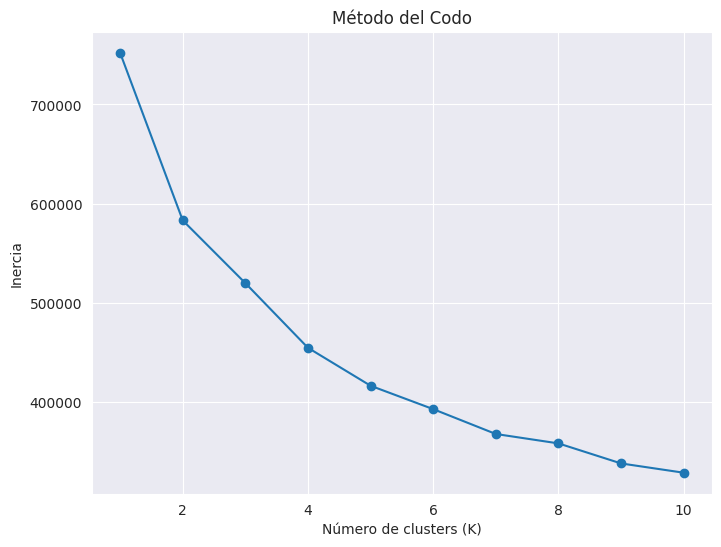

In [76]:
inertias = []
K_range = range(1, 11)  # Probar de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20)
    kmeans.fit(dfPreparado)
    inertias.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

In [89]:
K =4
kmeans = KMeans(n_clusters=K, init='k-means++', n_init=20)
y_predict = kmeans.fit_predict(dfPreparado)
centros = kmeans.cluster_centers_
print(f'Inercia del modelo: {kmeans.inertia_}')


NameError: name 'dfPreparado' is not defined

In [78]:
#df_completo = scaler.inverse_transform
dfBajas['CLUSTER'] = y_predict

# Guardar el DataFrame con los clusters en un archivo CSV
#df_completo.to_csv('/home/edgarrt/Files/Output/df_con_clusters.csv', index=False)
dfBajas.to_excel('/home/edgarrt/Files/Output/clusters_output2.xlsx', index=False)


In [79]:
# Evaluar la inercia
print(f'Inercia: {kmeans.inertia_}')

# Evaluar el índice de silueta
silhouette_avg = silhouette_score(dfPreparado, kmeans.labels_)
print(f'Índice de Silueta: {silhouette_avg}')

Inercia: 457004.71035534877
Índice de Silueta: 0.16912871990301054


In [80]:
# Reducir a 2 dimensiones usando PCA
pca = PCA(n_components=2)
df_reducido = pca.fit_transform(dfPreparado)

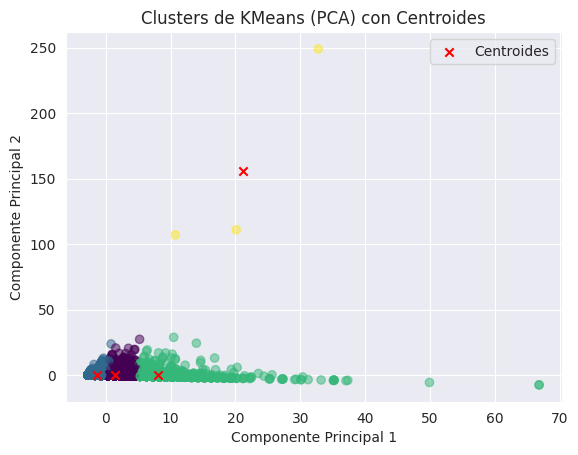

In [81]:
# Prepara data para mostra en grafica 2d con centroides
kmeans1 = KMeans(n_clusters=K, init='k-means++', n_init=20)
y_predict = kmeans1.fit_predict(df_reducido)
centros = kmeans1.cluster_centers_

# Visualizar los clusters en 2D
plt.scatter(df_reducido[:, 0], df_reducido[:, 1], c=y_predict, cmap='viridis', marker='o', alpha=0.5)
plt.scatter(centros[:, 0], centros[:, 1], c='red', marker='x', label='Centroides')  # Marcar los centroides
plt.title('Clusters de KMeans (PCA) con Centroides')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()

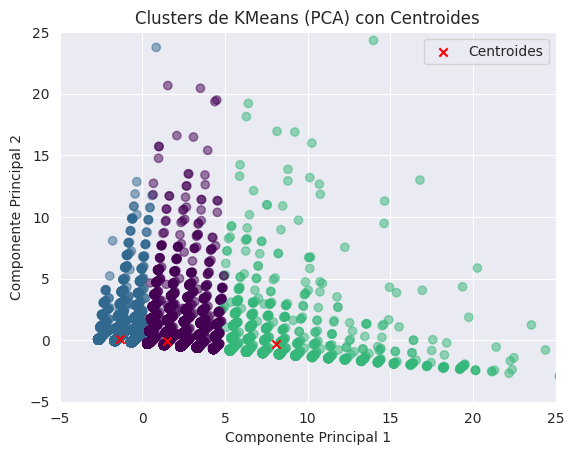

In [82]:
# Visualizar los clusters en 2D
plt.scatter(df_reducido[:, 0], df_reducido[:, 1], c=y_predict, cmap='viridis', marker='o', alpha=0.5)
plt.scatter(centros[:, 0], centros[:, 1], c='red', marker='x', label='Centroides')  # Marcar los centroides
plt.title('Clusters de KMeans (PCA) con Centroides')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
# Establecer los límites de los ejes
plt.xlim(-5, 25)  # Limitar el eje X desde 0 hasta 40
plt.ylim(-5, 25)  # Limitar el eje Y desde 0 hasta 100
plt.legend()
plt.show()

/tmp/ipykernel_1558/3066971687.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


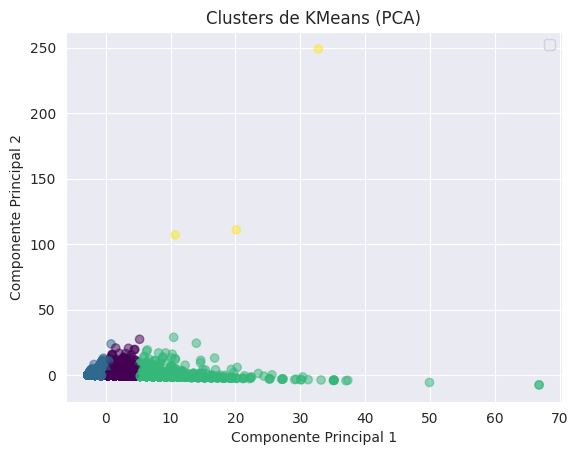

In [83]:
# Visualizar los clusters en 2D sin PCA
plt.scatter(df_reducido[:, 0], df_reducido[:, 1], c=y_predict, cmap='viridis', marker='o', alpha=0.5)
#plt.scatter(centros[:, 0], centros[:, 1], c='red', marker='x', label='Centroides')  # Marcar los centroides
plt.title('Clusters de KMeans (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()

/tmp/ipykernel_1558/3099402756.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


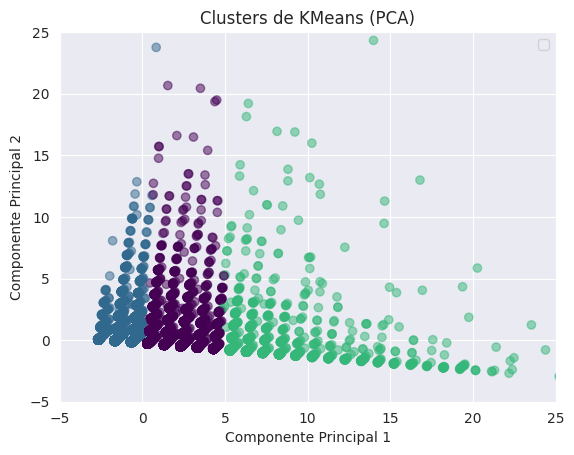

In [84]:
# Visualizar los clusters en 2D
plt.scatter(df_reducido[:, 0], df_reducido[:, 1], c=y_predict, cmap='viridis', marker='o', alpha=0.5)
#plt.scatter(centros[:, 0], centros[:, 1], c='red', marker='x', label='Centroides')  # Marcar los centroides
plt.title('Clusters de KMeans (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
# Establecer los límites de los ejes
plt.xlim(-5, 25)  # Limitar el eje X desde 0 hasta 40
plt.ylim(-5, 25)  # Limitar el eje Y desde 0 hasta 100
plt.legend()
plt.show()

In [85]:
# Reducir a 2 dimensiones usando PCA
pca = PCA(n_components=3)
df_reducido3d = pca.fit_transform(dfPreparado)

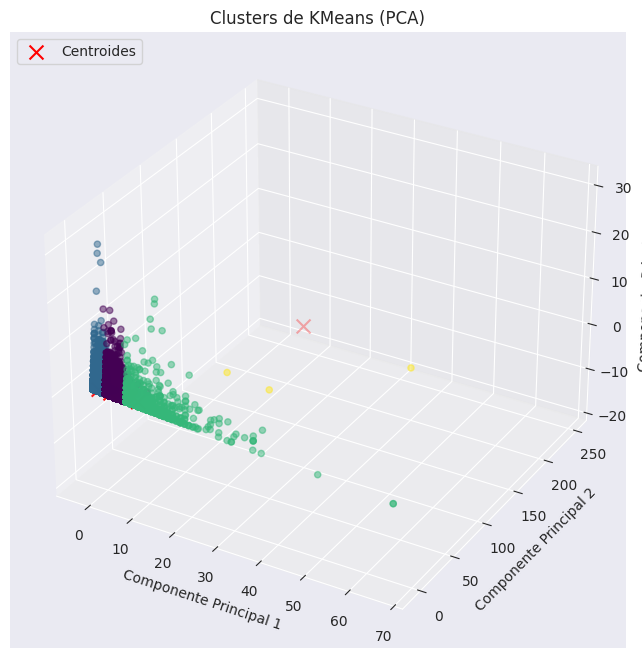

In [86]:
# Crear una figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar el scatter plot en 3D
scatter = ax.scatter(
    df_reducido3d[:, 0], 
    df_reducido3d[:, 1], 
    df_reducido3d[:, 2], 
    c=y_predict, 
    cmap='viridis', 
    marker='o', 
    alpha=0.5
)
# Dibujar los centroides en rojo
ax.scatter(
    centros[:, 0], 
    centros[:, 1], 
    c='red', 
    marker='x', 
    s=100, 
    label='Centroides'
)
# Configurar etiquetas y título
ax.set_title('Clusters de KMeans (PCA)')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.legend(loc='upper left')

plt.show()

In [87]:
import gc
import pandas as pd

# Identificar y eliminar todos los objetos de tipo DataFrame
for var in list(globals()):
    if isinstance(globals()[var], pd.DataFrame):
        del globals()[var]

# Llamar al recolector de basura para liberar la memoria
gc.collect()

819471

In [88]:
from IPython.display import display, Javascript

def restart_kernel():
    display(Javascript('''Jupyter.notebook.kernel.restart()'''))

restart_kernel()

<IPython.core.display.Javascript object>